In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

from matplotlib.lines import Line2D
color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00','#f0e442',
              '#cc79a7', '#56b4e9', '#000000']

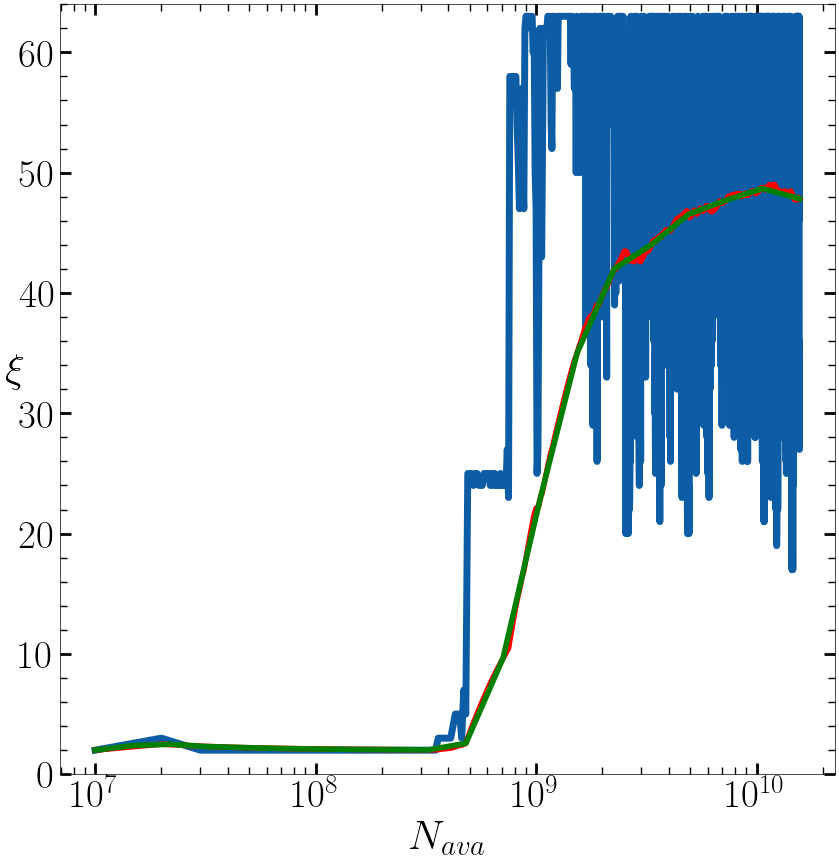

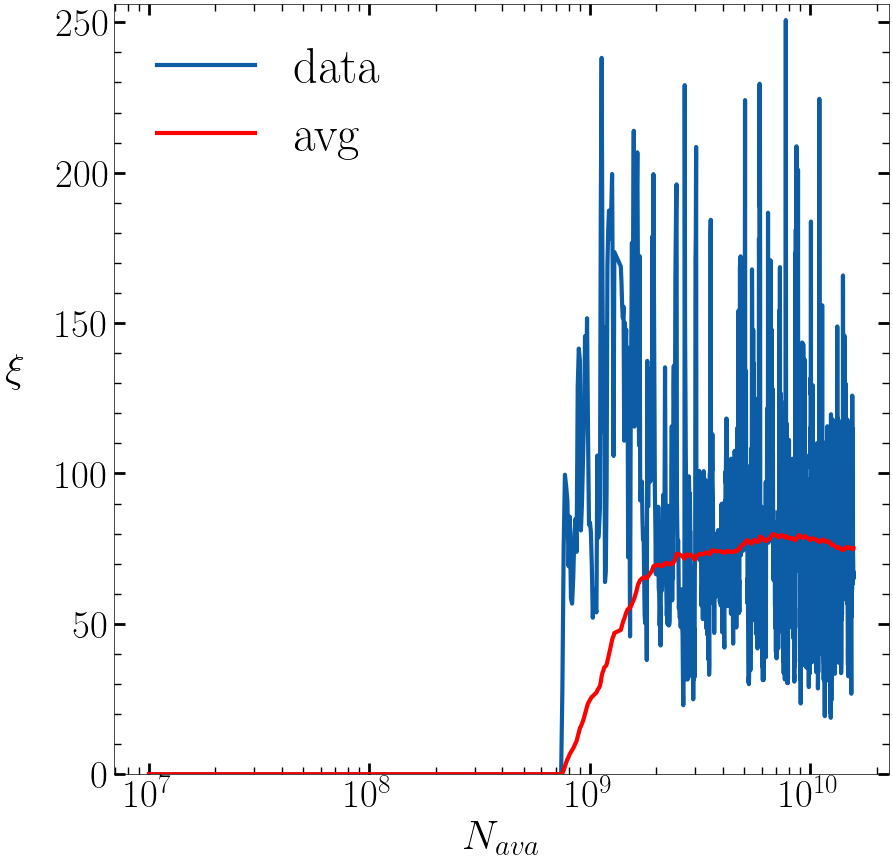

In [2]:
folderpath = '/data1/DATA_Duplat/Brut/Correlation2/Co1n7'
initime = 10000000
deltatime = 10000000
nbava = 15670000000
L2 = 256
clentab , avgtab = corrlength(folderpath, initime, deltatime, nbava, L2, 0)

filt_clenfit, filt_avgfit, avg_smooth= corrlengthfit(folderpath, L2, initime, deltatime, clentab,0)


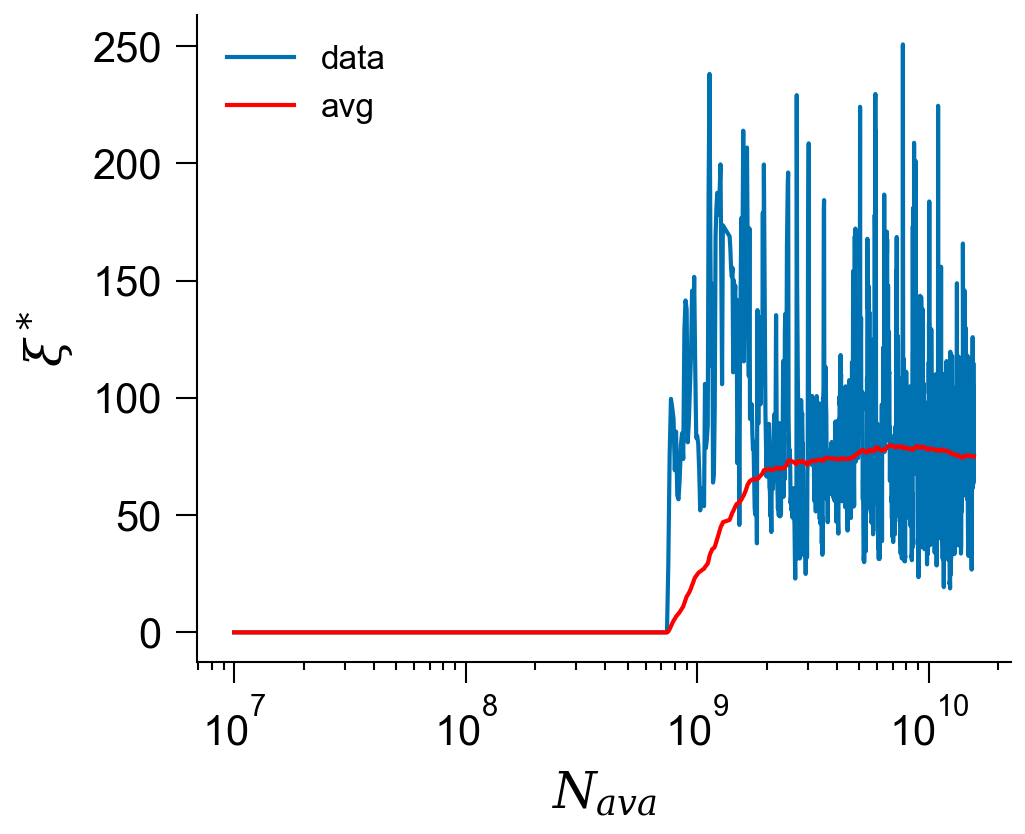

In [4]:
with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(figsize = (3.5,2.8))

    ax.plot(filt_clenfit[:, 0], filt_clenfit[:, 1], label = 'data', c = color_list[0])
    ax.plot(filt_clenfit[:, 0], filt_avgfit[:], label = 'avg', c = 'r')
    ax.set_xlabel("$N_{ava}$")
    ax.set_ylabel(r'$\xi^*$')
    ax.set_xscale("log")
    plt.savefig("xi(Nava).pdf", dpi = 600)
    fig.patch.set_alpha(0.0)
    plt.legend()
    plt.show()

In [32]:
nbproject = np.arange(1,4)
fnb = np.arange(1,9)
folderpath = "/data1/DATA_Duplat/Brut/Correlation2"

Tnu = [None]*len(fnb)
Time = np.zeros((len(nbproject), len(fnb)))
L1 = 0
L2 = 0
for i, n in enumerate(nbproject):
    for j, m in enumerate(fnb):
        subfolderpath = "{}/Co{}n{}".format(folderpath, n, m)
        params = read_parameters(subfolderpath)
        
        
        if i == 0:
            Tnu[j] = params[2]
        if j == 0: 
            L1 = params[0]
            L2 = params[1]
            

        iniava = params[19][0]
        deltaava = params[19][1]
        nbava = params[8]
        
        #print(i, j, iniava, deltaava, nbava)
        clentab , avgtab = corrlength(subfolderpath, iniava, deltaava, nbava, L2, numcol=0, switch_plot= 0)
        filt_clenfit, filt_avgfit, _ = corrlengthfit(subfolderpath, L2, iniava, deltaava, clentab, numcol = 0, switch_plot= 0)
        
        # mask = filt_avgfit != 0
        # filt_avgfit=filt_avgfit[mask]

        id = np.where(filt_clenfit[:,1] > filt_avgfit[-1])[0][0]
        Time[i,j] = filt_clenfit[id,0]
        


/home/kduplat/Documents/py38/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [ ]:
#Correction visuelle dans le cas nu = 0.03
Size = [256,128,64]

Time[1,0] = 1e5
Time[2,0] = 1e4
Time[2,1] = 3e4

[1.70e+06 3.40e+06 6.80e+06 1.57e+07 4.10e+07 9.10e+07 7.70e+08 8.60e+09]
[1.00e+05 5.10e+05 8.80e+05 1.76e+06 4.80e+06 1.11e+07 4.40e+07 2.90e+08]
[1.00e+04 3.00e+04 8.30e+04 1.86e+05 3.10e+05 7.80e+05 4.00e+06 1.60e+07]


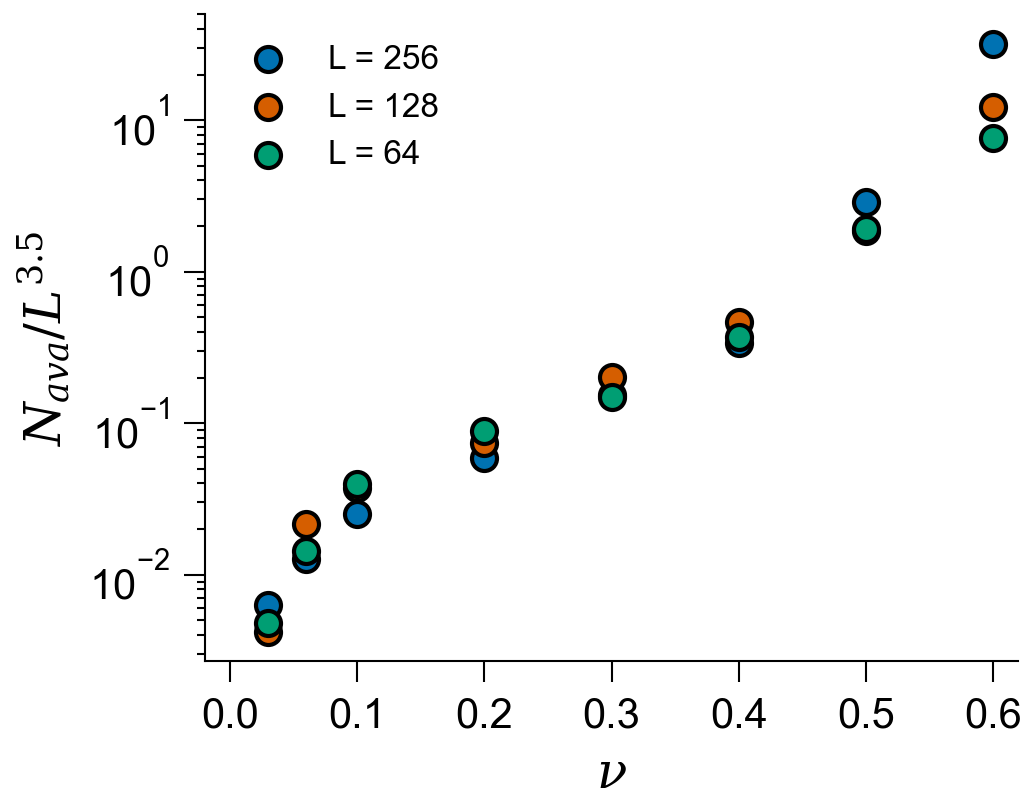

In [70]:

with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(figsize = (3.5,2.8))
    for i, n in enumerate(nbproject):
        print(Time[i])
        ax.scatter(Tnu, Time[i]/(Size[i]**3.5), c = color_list[i], label = "L = {}".format(Size[i]))
        
    ax.legend()
    ax.set_yscale('log')
    ax.set_xlim(-0.02,0.62)
    ax.set_xlabel(r"$\nu$")
    ax.set_ylabel(r"$N_{ava}/L^{3.5}$")
    ax.set_xticks([0,0.1,0.2,0.3, 0.4, 0.5, 0.6])
    plt.savefig("Transient_time.pdf", dpi = 600)
    plt.show()
            

        

#   Panorama

##  P(s)

In [3]:
L1 = 64
L2 = 512
nbins = 11

def PDFfig(folderpath, L1, L2, nbins):
    avatab = np.loadtxt(f'{folderpath}/Avalanche_outputB.txt')
        
    lenghtTab = L1 * L2
    histo, bins = np.histogram(avatab[:, 1], bins = np.arange(lenghtTab+2))   
    ndatafit, ndistloglog, nstat = mainfct(histo, lenghtTab, nbins)
    davg = np.mean(avatab[:,1])
    return nstat[0], davg

In [4]:

folderpath = '/home/kduplat/Documents/Data/Brut/OFC*gaus/OF6n'
std =  [0, 0.01, 0.02, 0.03, 0.04]
nu = [0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
nbf = int(len(std)* len(nu))
nbfolder = np.arange(1, nbf +1)
btab = np.zeros((len(std), len(nu)))
avgtab = np.zeros((len(std), len(nu)))
nbins = 11
for nb in nbfolder: 
    b, davg = PDFfig(f'{folderpath}{nb}', L1, L2, nbins)
    i = (nb - 1) % len(std) 
    j = (nb - 1) // len(std)
    btab[i][j] = b
    avgtab[i][j] = davg
    
btab = np.array(-btab)
avgtab = np.array(avgtab)

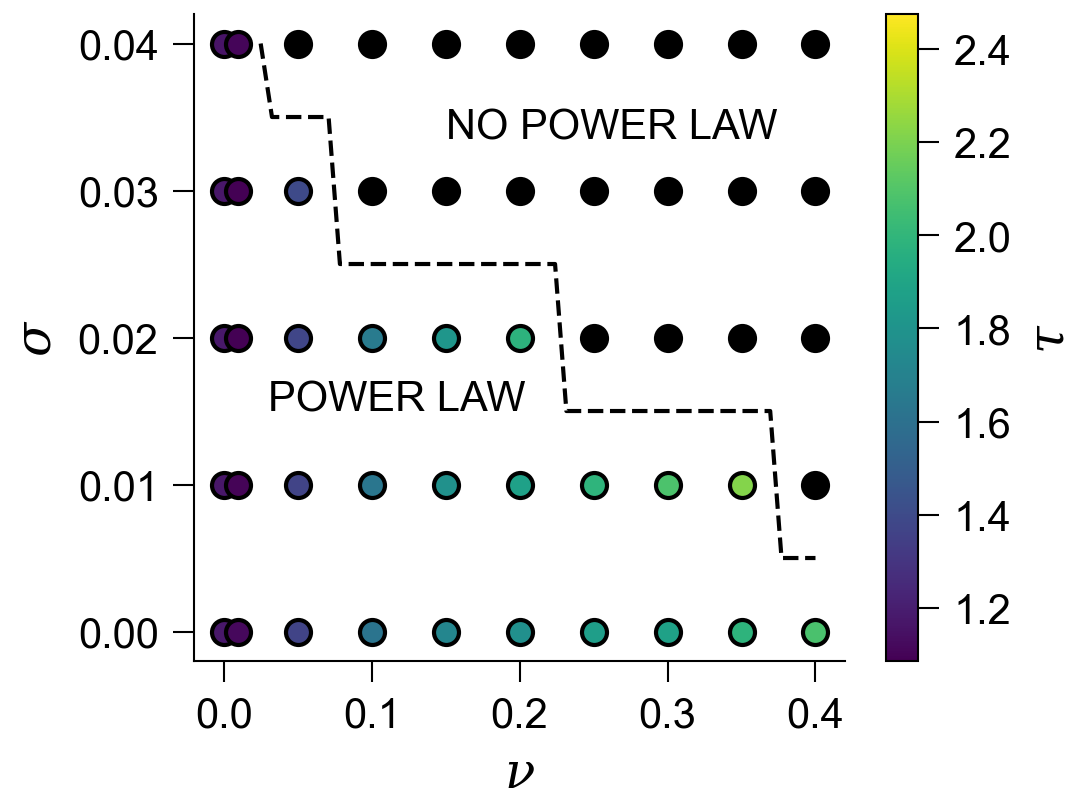

In [18]:

array1 = np.array([15,19,20, 24,25,29,30,33,34,35,38,39,40,43,44,45,47, 48,49,50])
array1 = array1 - 1
avgtab2 = np.reshape(avgtab.T, (50))
avgmin2 = np.min(avgtab2[array1])
avgmax2 = np.max(avgtab2[array1])

array2 = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,16,17,18,19,21,22,23,26,27,28,31,32,36,37,41,42,43,44,46])
array2 = array2 - 1
btab2 = np.reshape(btab.T, (50))
bmin2 = np.min(btab2[array2])
bmax2 = np.max(btab2[array2])


colors = 'viridis'
with plt.style.context(spstyle.get_style('thesis')):

    fig, ax = plt.subplots(figsize = (3.5,2.8))
    nb = 1
    for j, dis in enumerate(nu):
        for i, dev in enumerate(std):
            if nb in array1+1:
                test2 = plt.scatter(dis, dev, color = 'k')
            else:
                pos = plt.scatter(dis, dev, c = btab[i][j], cmap = colors, vmin = bmin2, vmax = bmax2 - 0.5)
                
            nb += 1

    xlim = [0.025, 0.0250001, 0.075, 0.07500001, 0.225, 0.225, 0.375, 0.375, 0.4]
    ylim = [0.04, 0.035, 0.035, 0.025, 0.025, 0.015, 0.015, 0.005, 0.005]

    x_plot = np.linspace(xlim[0], xlim[-1], 50)
    y_plot = np.interp(x_plot, xlim, ylim)
    y_plot = np.round(y_plot, decimals = 4)
    ax.plot(x_plot, y_plot, linestyle = '--', color = 'k')


    ax.set_xlabel(r'$\nu$')
    ax.set_ylabel(r'$\sigma$')
    y_ticks_to_display = [0, 0.01, 0.02, 0.03, 0.04]
    ax.set_yticks(y_ticks_to_display)
    
    cbar = fig.colorbar(pos)
    cbar.set_label(r'$\tau$')
    # cbar.ax.tick_params(labelsize = 25, length = 11, width = 2 , which = 'major')
    # cbar.ax.tick_params(length = 7, width = 1, which = 'minor')

    """ plt.legend((test, test2), ('Power law', 'Avg'), bbox_to_anchor = (0.25, 0.80), fontsize = 16) """

    ax.text(0.03, 0.015, 'POWER LAW', fontsize = 10)
    ax.text(0.15, 0.0335, 'NO POWER LAW', fontsize = 10)

    # ax.text(-0.005, 0.001, '1')
    # ax.text(0.0095, 0.001, '2')
    # ax.text(0.195, 0.001, '3')
    # ax.text(0.395, 0.001, '4')
    # ax.text(0.395, 0.0029, 'a')
    # ax.text(0.395, 0.011, 'b')
    # ax.text(0.395, 0.021, 'c')
    # ax.text(0.395, 0.037, 'd')
    plt.savefig("Pano1.pdf", dpi = 600)
    plt.show()


##  Intertime

In [6]:
def powerlaw2(log_x, a, b):
    return a + b * log_x

def gamma_distribution(x, A, n, B):
    return A * x**n * np.exp(-x / B)

def TBA2(folderpath, vartab, L1, L2, nbins, var, switch = 0, size = 1, switch_plot = 1): #PDF time between avalanches for multiple folders
    linestyle_tuple = [('dashed', (0, (5, 5))),
                    ('dotted', (0, (1, 1))),
                    ('dashdotted', (0, (3, 5, 1, 5))),
                    ('long dash with offset', (5, (10, 3))),
                    ('loosely dotted', (0, (1, 10)))]
    
    NCURVES = len(folderpath)
    cmap = plt.cm.get_cmap('inferno')
    colors = [cmap(i / NCURVES) for i in range(NCURVES)]
    
    plt.figure(figsize = (20,10))
    ax1 = plt.subplot(1,2,1)
    Tb, Tb2 = np.zeros(len(folderpath)), np.zeros(len(folderpath))
    
    for i, (folder, c , v) in enumerate(zip(folderpath, colors[:], vartab)):
        
        if os.path.exists(f'{folder}/Avalanche_outputB.txt'):
            avatab = np.loadtxt(f'{folder}/Avalanche_outputB.txt')
        else :
            with gzip.open(f'{folder}/Avalanche_outputB.gz', "rb") as f:
                data_bytes = f.read().decode('utf-8') 
                        
                lignes = data_bytes.strip().split('\n')
                avatab = np.array([ligne.split() for ligne in lignes], dtype=np.float32)
                
        avatab = avatab[avatab[:, 1] >= size]
        avatab = avatab[:, 3]
        t_mean = np.mean(avatab)
        Emax = max(avatab)/t_mean
        Emin = min(avatab)/t_mean
        
        histo2, bins2 = np.histogram(avatab/t_mean, bins = np.logspace(np.log10(10**-6), np.log10(Emax), nbins), density = 1)
        """ histo2 = histo2 / sum(histo2) """
        
        popt, _ = curve_fit(powerlaw2, np.log(bins2[11:22]), np.log(histo2[11:22]))
        a,b = popt
        yfit = np.exp(powerlaw2(np.log(bins2[11:22]), *popt))
        
        popt2, _ = curve_fit(powerlaw2, np.log(bins2[:10]), np.log(histo2[:10]))
        a2,b2 = popt2
        yfit2 = np.exp(powerlaw2(np.log(bins2[:10]), *popt2))
        
        Tb[i] = b
        Tb2[i] = b2

    
        ax1.plot(bins2[:-1], histo2 , color = c, label = f'{v}', marker = 'o', linewidth = 3)
        """ ax1.plot(bins2[11:22], yfit, linestyle = "--", color = 'k', linewidth = 3)
        ax1.plot(bins2[:10], yfit2, linestyle = "--", color = 'b', linewidth = 3) """
    
    """ fgamma = gamma_distribution(bins2, 0.5, -0.3, 1.58)
    ax1.plot(bins2, fgamma, color = 'k') """
    
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
    ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
    ax1.tick_params(labelsize = 28,length = 8, width = 2)
    ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
    ax1.set_xlim(1e-6, 1e2)
    ax1.legend(title = rf'$\nu$', fontsize = 23, title_fontsize = 23)
    
    
    if switch_plot == 1:
        ax2 = plt.subplot(1,2,2)
        
        ax2.plot(vartab, -Tb, color  = 'k')
        ax2.plot(vartab, -Tb2, color  = 'k')
        """ plt.xscale('log')
        plt.yscale('log') """
        ax2.set_xlabel(r'$\nu$', fontsize = 30)
        ax2.set_ylabel('b', fontsize = 30)
        ax2.tick_params(labelsize = 28,length = 8, width = 2)
        ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
    
    plt.show()
    
    del avatab
    
    return Tb, Tb2

/tmp/ipykernel_1660449/4268136500.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('inferno')


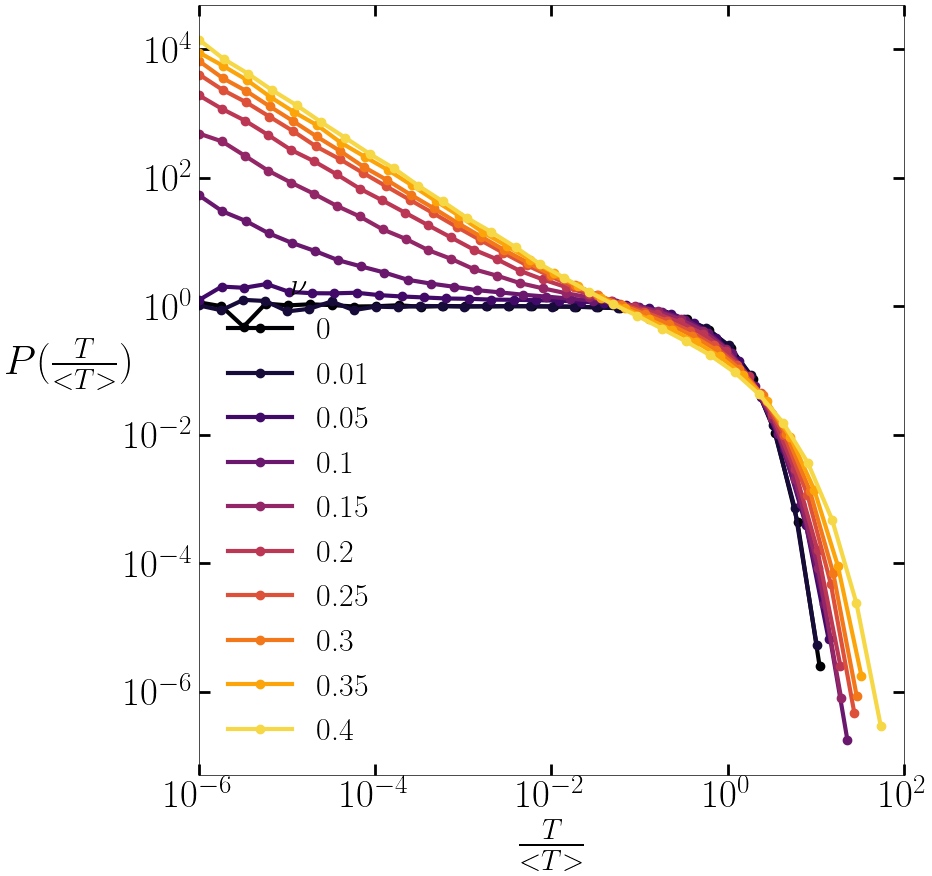

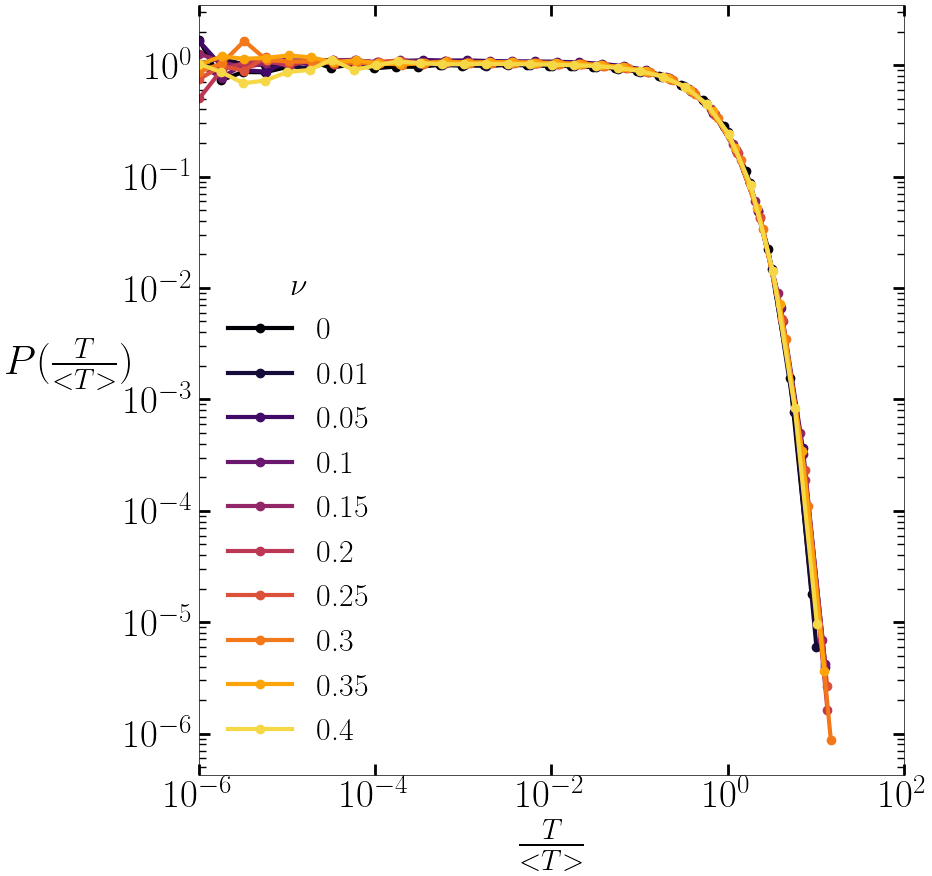

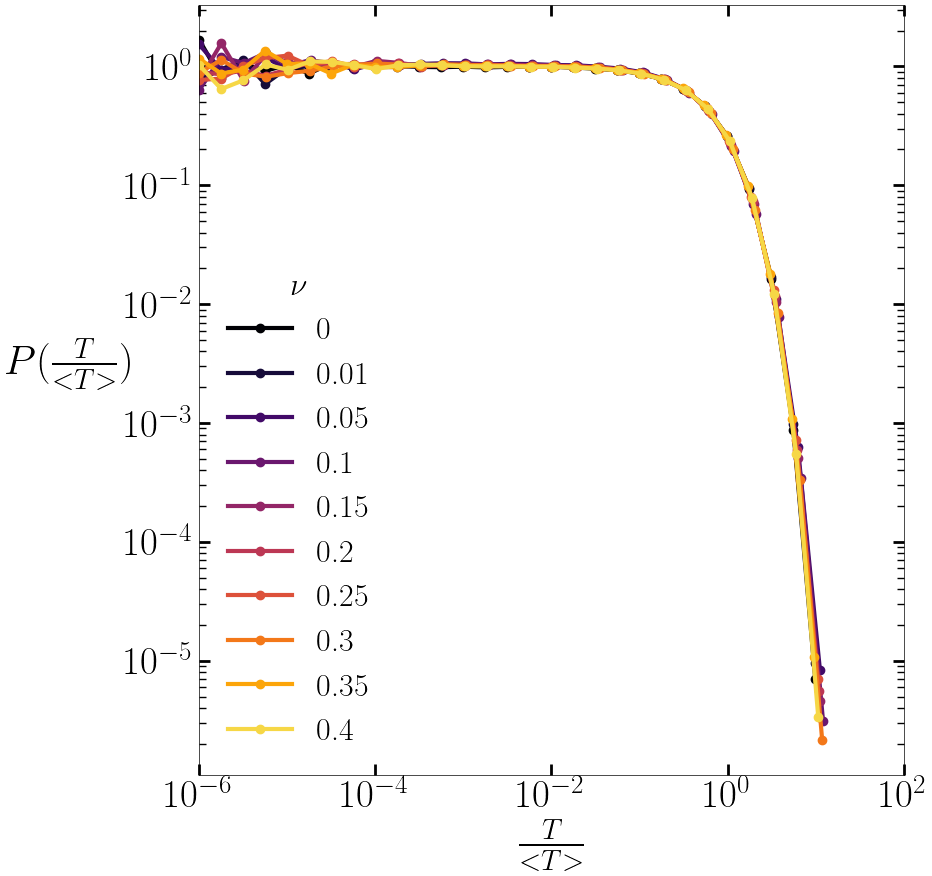

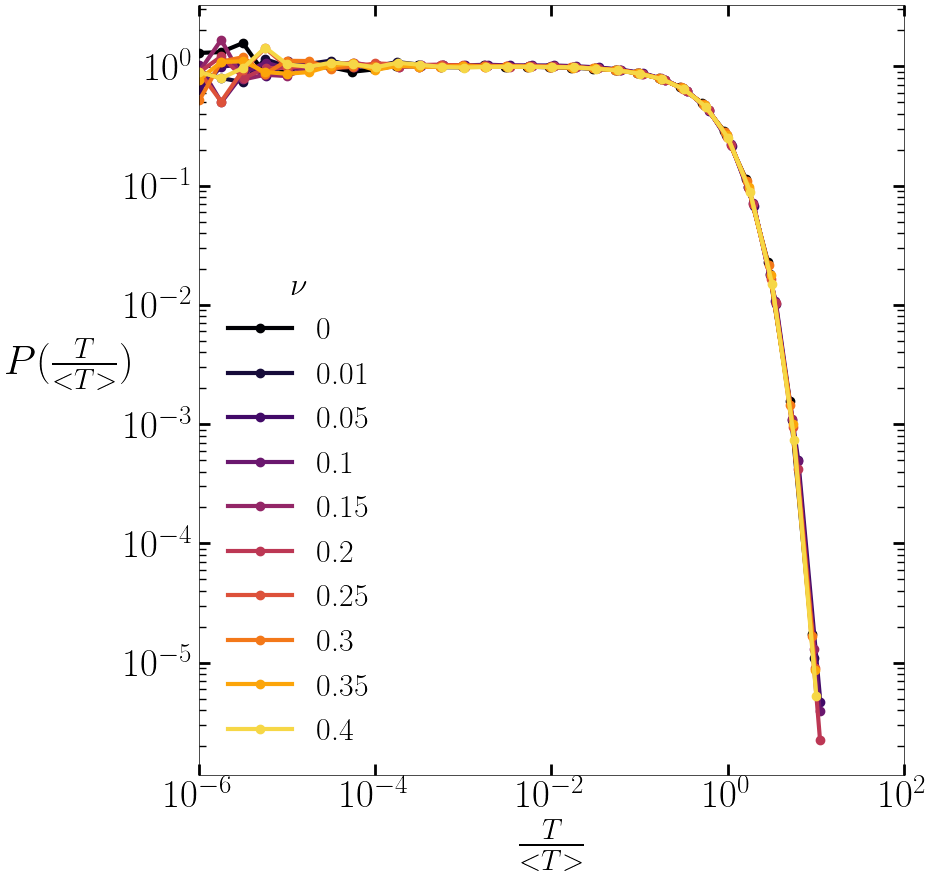

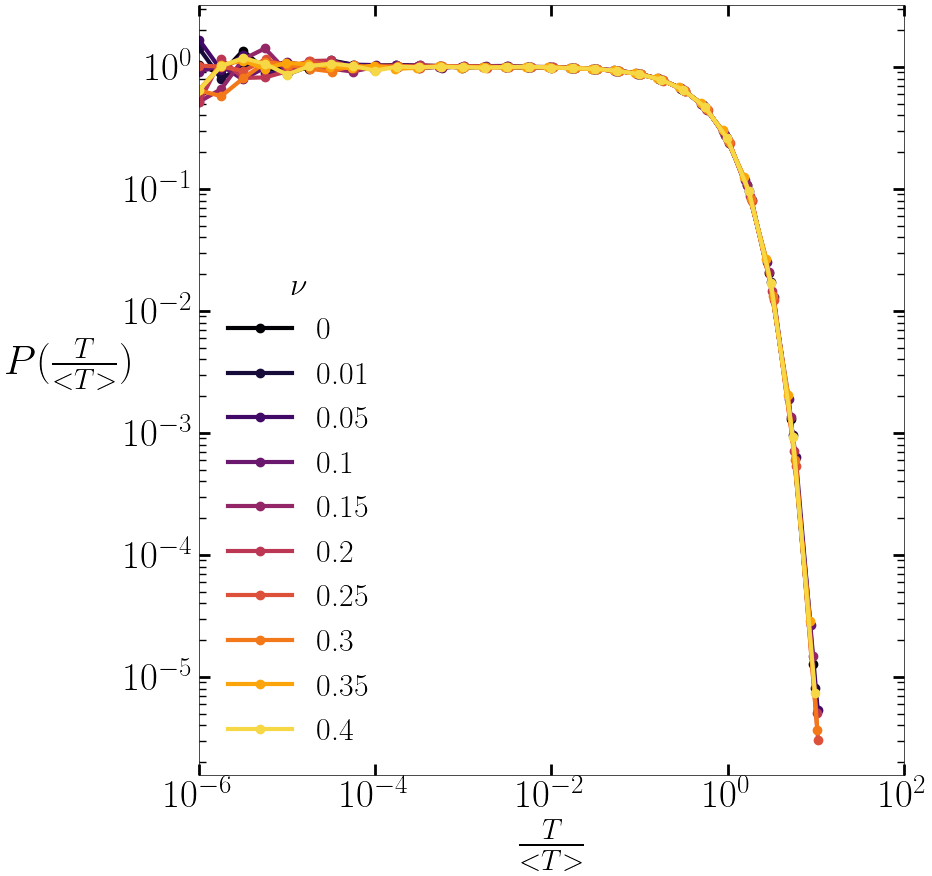

In [7]:


L1 = 64
L2 = 512
nbins = 30
var = 'nu'
Tnu = [ 0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

folderpath = '/home/kduplat/Documents/Data/Brut/OFC*gaus/OF6n'

foldernb = [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]
completefpath = [f'{folderpath}{foldernb[i]}' for i in range(len(foldernb))]
Tb0, Tb20 = TBA2(completefpath, Tnu, L1, L2, nbins, var, size = 1, switch_plot = 0)

foldernb = [2, 7, 12, 17, 22, 27, 32, 37, 42, 47]
completefpath = [f'{folderpath}{foldernb[i]}' for i in range(len(foldernb))]
Tb1, Tb21 = TBA2(completefpath, Tnu, L1, L2, nbins, var, size = 1, switch_plot = 0)

foldernb = [3, 8, 13, 18, 23, 28, 33, 38, 43, 48]
completefpath = [f'{folderpath}{foldernb[i]}' for i in range(len(foldernb))]
Tb2, Tb22 = TBA2(completefpath, Tnu, L1, L2, nbins, var, size = 1, switch_plot = 0)

foldernb = [4, 9, 14, 19, 24, 29, 34, 39, 44, 49]
completefpath = [f'{folderpath}{foldernb[i]}' for i in range(len(foldernb))]
Tb3, Tb23 = TBA2(completefpath, Tnu, L1, L2, nbins, var, size = 1, switch_plot = 0)

foldernb = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
completefpath = [f'{folderpath}{foldernb[i]}' for i in range(len(foldernb))]
Tb4, Tb24 = TBA2(completefpath, Tnu, L1, L2, nbins, var, size = 1, switch_plot = 0)

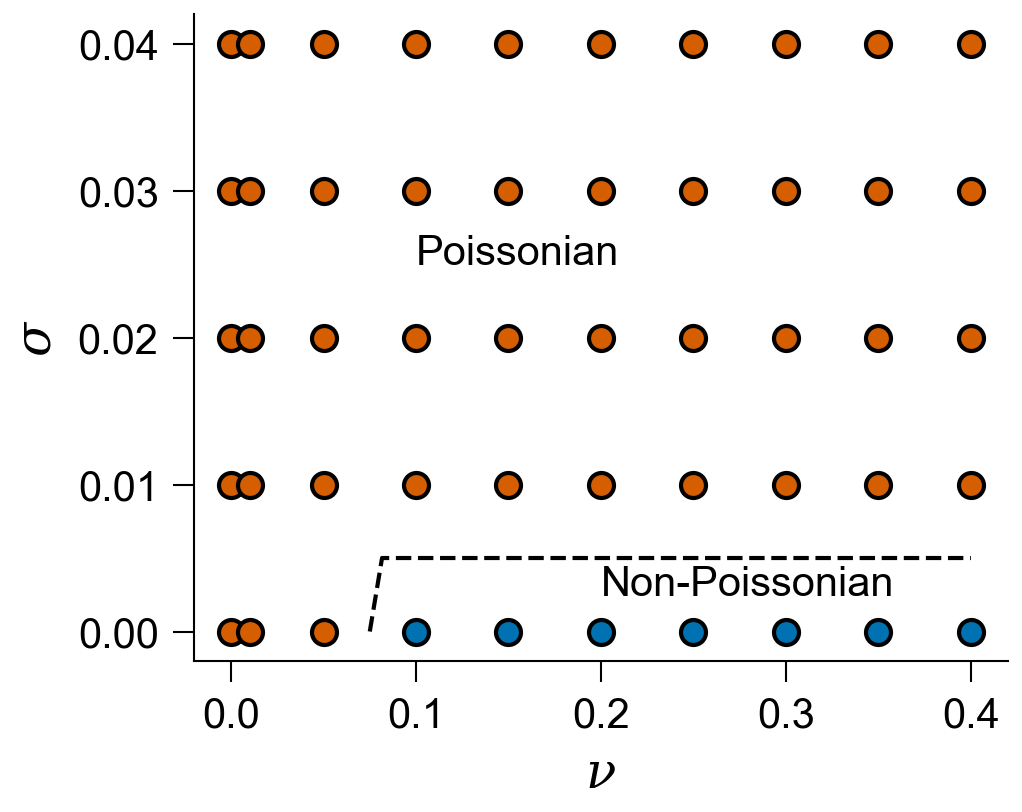

In [14]:


Tnu = [ 0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
Tdis = [0,0.01,0.02,0.03,0.04]

""" std0 = [0 for _ in range(len(Tnu))]
std001 = [0.01 for _ in range(len(Tnu))]
std002 = [0.02 for _ in range(len(Tnu))]
std003 = [0.03 for _ in range(len(Tnu))]
std004 = [0.04 for _ in range(len(Tnu))] """

Tteta = np.column_stack((Tb0, Tb1, Tb2, Tb3, Tb4))
Tteta2 = np.column_stack((Tb20, Tb21,Tb22, Tb23, Tb24))


colors = 'viridis'
with plt.style.context(spstyle.get_style('thesis')):

    fig, ax = plt.subplots(figsize= (3.5,2.8))
    for j, dis in enumerate(Tdis):
        for i, dev in enumerate(Tnu):

            if -Tteta[i][j] >0.1:
                pos = ax.scatter(dev, dis, c = color_list[0]) 
            else:
                pos = ax.scatter(dev, dis, c = color_list[1]) 

    xlim = [0.075, 0.07500001, 0.4]
    ylim = [0.000, 0.005, 0.005]

    x_plot = np.linspace(xlim[0], xlim[-1], 50)
    y_plot = np.interp(x_plot, xlim, ylim)
    y_plot = np.round(y_plot, decimals = 4)
    """ y_plot = np.round(y_plot, decimals = 4) """

    ax.plot(x_plot, y_plot, linestyle = '--', color = 'k')
    y_ticks_to_display = [0, 0.01, 0.02, 0.03, 0.04]
    x_ticks_to_display = [0, 0.1, 0.2, 0.3, 0.4]
    ax.set_xlabel(r'$\nu$')
    ax.set_ylabel(r'$\sigma$')

    # cbar = fig.colorbar(pos)
    # cbar.set_label(r'$\gamma$')



    ax.text(0.1, 0.025, 'Poissonian', fontsize = 10)
    ax.text(0.2, 0.0025, 'Non-Poissonian', fontsize = 10)

    ax.set_xlim(min(Tnu) - 0.02, max(Tnu) + 0.02)
    ax.set_ylim(min(Tdis) - 0.002, max(Tdis) + 0.002)
    ax.set_yticks(y_ticks_to_display)
    ax.set_xticks(x_ticks_to_display)
    plt.savefig("Pano2.pdf", dpi = 600)
    plt.show()

10000001
0.9242055458607512
10000001
0.5469721049925295
10000001
10000001


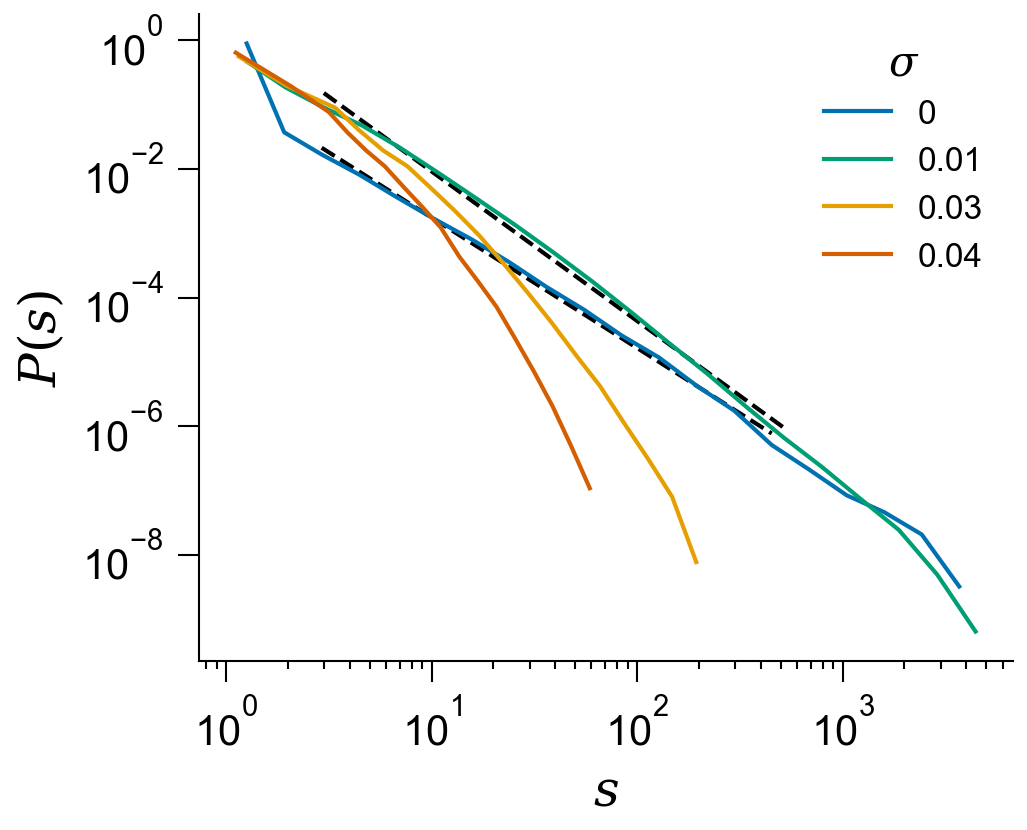

In [ ]:
 
folderpath = '/home/kduplat/Documents/Data/Brut/OFC*gaus/OF6n'
L1 = 64
L2 = 512
nbins = 20

fnb = [46, 47,49,50]

Tstart_x = [2,2]
Tstop_x = [1e3, 1e3]

Tfolderpath = [f'{folderpath}{nb}' for nb in fnb]
bins = np.arange(L1*L2 +1)
std = [0, 0.01, 0.03, 0.04]

with plt.style.context(spstyle.get_style('thesis')):

    fig, ax = plt.subplots(figsize= (3.5,2.8))
    for i, folder in enumerate(Tfolderpath):
        data = np.loadtxt("{}/Avalanche_outputB.txt".format(folder), usecols = [1])
        histo, bins = np.histogram(data, bins = np.arange(L1*L2 +1))
        
        last_non_zero = np.nonzero(histo)[0]
        nmax = last_non_zero[-1]
        if nbins == 0:
            nbins = freedman_diaconis_log_bins(histo[:nmax])
            if nbins > len(histo):
                nbins = len(histo) -1
        if nbins > 300:
            nbins = 300
        mean = np.sum(histo * np.arange(len(histo)))/np.sum(histo)
        bins, histo = new_logbins(histo[:nmax], nbins) #Transforme les bins lin en bins log
        bin_center = (bins[1:] + bins[:-1])/2

        mask = histo != 0
        f_histo = histo[mask]
        f_bin_center = bin_center[mask]

        if i <=1:
            xfit, yfit, _, _= PDF_fitting([f_histo], [f_bin_center], [Tstart_x[i]], [Tstop_x[i]], std)

            ax.plot(xfit[0], yfit[0], 'k--')
        ax.plot(f_bin_center, f_histo, c = color_list[i], label = std[i])
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$P(s)$')
    
    ax.legend(title  = r"$\sigma$")
    plt.savefig("P(s)_disorder.pdf", dpi = 300)
    plt.show()

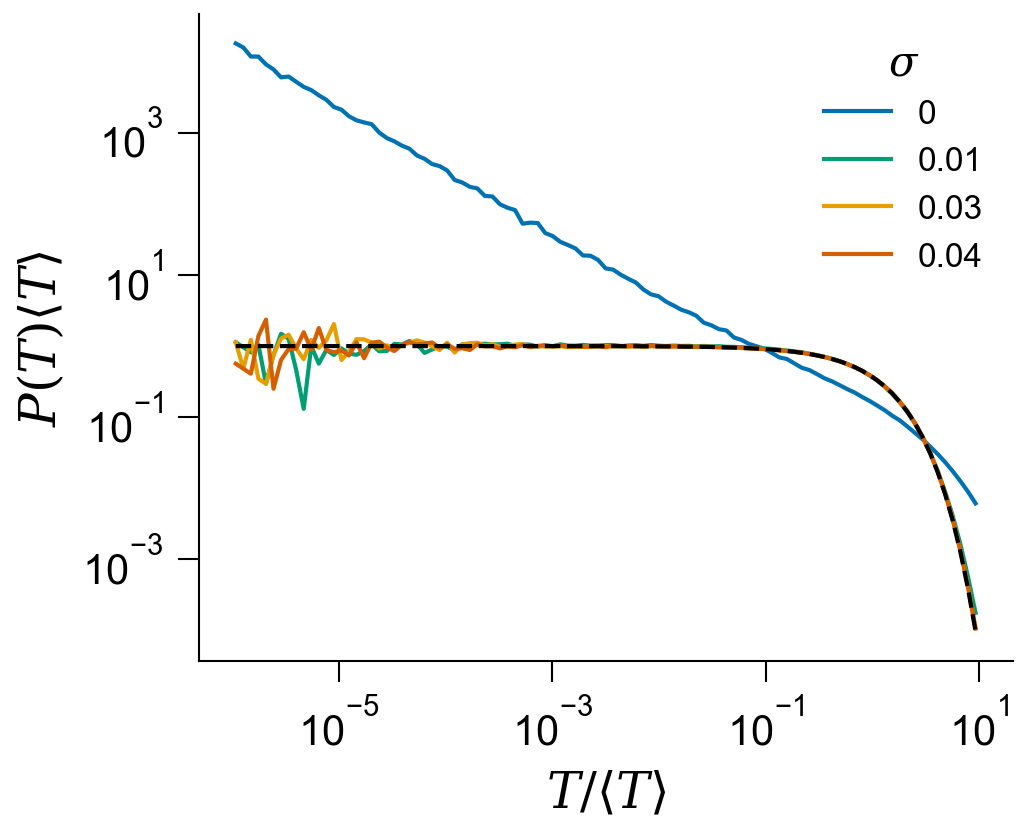

In [53]:
 
folderpath = '/home/kduplat/Documents/Data/Brut/OFC*gaus/OF6n'
L1 = 64
L2 = 512
nbins = 20

fnb = [46, 47,49,50]

Tstart_x = [2,2]
Tstop_x = [1e3, 1e3]

Tfolderpath = [f'{folderpath}{nb}' for nb in fnb]
bins = np.logspace(np.log10(10**-6), np.log10(10), 100)
std = [0, 0.01, 0.03, 0.04]

with plt.style.context(spstyle.get_style('thesis')):

    fig, ax = plt.subplots(figsize= (3.5,2.8))
    for i, folder in enumerate(Tfolderpath):
        data = np.loadtxt("{}/Avalanche_outputB.txt".format(folder), usecols = [3])
        
        t_mean = np.mean(data)
        
        histo, bins = np.histogram(data/t_mean, bins = bins, density = True)
        bin_center = (bins[:-1] + bins[1:])/2
        
        mask = histo !=0
        
        f_bin_center = bin_center[mask]
        f_histo = histo[mask]
        ax.plot(f_bin_center, f_histo, c = color_list[i], label = std[i])
        
        if i == 3:
            poisson = expfct(f_bin_center, 1, -1.0 )
            ax.plot(f_bin_center, poisson, linestyle = '--', color = 'k')
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$T/\langle T \rangle$')
    ax.set_ylabel(r'$P(T)\langle T \rangle$')
    ax.legend(title  = r"$\sigma$")
    plt.savefig("P(T)_disorder.pdf", dpi = 300)
    plt.show()

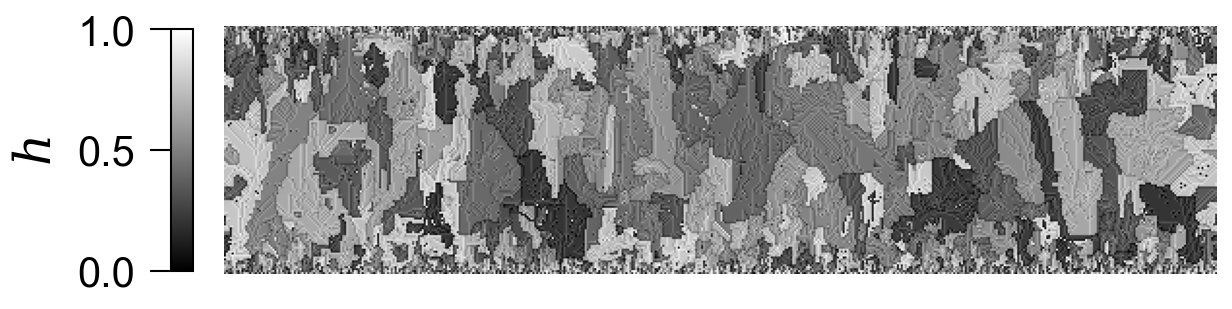

In [4]:

L1 = 128
L2 = 512

sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/Configurations/Co38n7/Snapshots/nav20000000000_outputB.txt", comments='#').reshape(L2, L1).T


with plt.style.context(spstyle.get_style('thesis')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, axis = plt.subplots(1,1, figsize = (4.5, 2.8))
    pos = axis.imshow( 1- sys1, cmap = "gray", vmin = 0, vmax = 1)
    
    axis.set_axis_off()
    
    cbar = fig.colorbar(pos, ax=axis, location = 'left', fraction=0.021, aspect = 11, pad = 0.03)
    cbar.set_label(r'$h$')
    
    plt.savefig("Snapshot.pdf", dpi = 600)
    plt.show()